# 08 - LightGBM Forecasting Model

## Analytical Objectives

- Load the feature-engineered Walmart dataset.
- Prepare the data for LightGBM regression.
- Preserve chronological order during train-test splitting.
- Train a LightGBM sales forecasting model.
- Use historical, calendar, holiday, store, department, and economic features.
- Generate future weekly sales predictions.
- Evaluate performance using MAE, RMSE, and MAPE.
- Analyze actual versus predicted sales.
- Analyze forecasting residuals.
- Identify important predictive features.
- Compare LightGBM against the Naïve Baseline, Prophet, and XGBoost.
- Save the trained model, predictions, and evaluation results.

## Expected Outcome

By the end of this notebook, we will have:

- A trained LightGBM forecasting model.
- Weekly sales predictions.
- Model evaluation metrics.
- Feature importance analysis.
- A complete comparison of the forecasting models developed so far.

#### Install LightGBM

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib
import os

from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

#### Load Feature Engineered Dataset

In [2]:
train = pd.read_csv(
    "../data/processed/train_feature_engineered.csv"
)

train["Date"] = pd.to_datetime(
    train["Date"]
)

train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,Dept_Sales_Rank,Dept_Sales_Contribution,Month_Sin,Month_Cos,Week_Sin,Week_Cos,Quarter_Sin,Quarter_Cos,DayOfWeek_Sin,DayOfWeek_Cos
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,...,21,1.83516,0.866025,5.000000e-01,0.568065,0.822984,1.0,6.123234e-17,-0.433884,-0.900969
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,...,21,1.83516,0.866025,5.000000e-01,0.663123,0.748511,1.0,6.123234e-17,-0.433884,-0.900969
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,...,21,1.83516,0.866025,5.000000e-01,0.748511,0.663123,1.0,6.123234e-17,-0.433884,-0.900969
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,...,21,1.83516,0.866025,5.000000e-01,0.822984,0.568065,1.0,6.123234e-17,-0.433884,-0.900969
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,...,21,1.83516,1.000000,6.123234e-17,0.885456,0.464723,1.0,6.123234e-17,-0.433884,-0.900969


In [3]:
print("Dataset Shape:", train.shape)

Dataset Shape: (421570, 66)


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 66 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Store                    421570 non-null  int64         
 1   Dept                     421570 non-null  int64         
 2   Date                     421570 non-null  datetime64[us]
 3   Weekly_Sales             421570 non-null  float64       
 4   IsHoliday                421570 non-null  bool          
 5   Type                     421570 non-null  str           
 6   Size                     421570 non-null  int64         
 7   Temperature              421570 non-null  float64       
 8   Fuel_Price               421570 non-null  float64       
 9   MarkDown1                421570 non-null  float64       
 10  MarkDown2                421570 non-null  float64       
 11  MarkDown3                421570 non-null  float64       
 12  MarkDown4                42

#### Sort Chronologically

In [5]:
train = train.sort_values(
    ["Date", "Store", "Dept"]
).reset_index(drop=True)

In [6]:
train[
    ["Date", "Store", "Dept", "Weekly_Sales"]
].head(10)

,Date,Store,Dept,Weekly_Sales
0,2010-02-05,1,1,24924.50
1,2010-02-05,1,2,50605.27
2,2010-02-05,1,3,13740.12
3,2010-02-05,1,4,39954.04
4,2010-02-05,1,5,32229.38
5,2010-02-05,1,6,5749.03
6,2010-02-05,1,7,21084.08
7,2010-02-05,1,8,40129.01
8,2010-02-05,1,9,16930.99
9,2010-02-05,1,10,30721.50


In [7]:
#Define Target

target = "Weekly_Sales"

In [8]:
#Select Features

feature_columns = [

    # Store / Department
    "Store",
    "Dept",

    # Calendar
    "Year",
    "Quarter",
    "Month",
    "Week",
    "Day",
    "DayOfWeek",
    "IsWeekend",

    # Holiday
    "Holiday_Flag",
    "Previous_Holiday",
    "Next_Holiday",
    "Near_Holiday",

    # External variables
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",

    # Lag features
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_8",
    "Lag_12",
    "Lag_52",

    # Rolling features
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Mean_12",
    "Rolling_Std_4",
    "Rolling_Std_8",
    "Rolling_Std_12",
    "Rolling_Min_4",
    "Rolling_Max_4",

    # Expanding features
    "Expanding_Mean",
    "Expanding_Std",
    "Expanding_Min",
    "Expanding_Max",

    # Store features
    "Store_Avg_Sales",
    "Store_Std_Sales",
    "Store_Min_Sales",
    "Store_Max_Sales",
    "Store_Sales_Rank",
    "Store_Type",
    "Store_Size_Relative",

    # Department features
    "Dept_Avg_Sales",
    "Dept_Std_Sales",
    "Dept_Min_Sales",
    "Dept_Max_Sales",
    "Dept_Sales_Rank",
    "Dept_Sales_Contribution",

    # Cyclical features
    "Month_Sin",
    "Month_Cos",
    "Week_Sin",
    "Week_Cos",
    "Quarter_Sin",
    "Quarter_Cos",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos"
]

#### Create X and y

In [9]:
X = train[feature_columns]

y = train[target]

In [10]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (421570, 56)
y Shape: (421570,)


#### Time-Based Train-Test Split

In [11]:
split_date = pd.Timestamp(
    "2012-06-01"
)

In [13]:
#Create masks:

train_mask = train["Date"] < split_date

test_mask = train["Date"] >= split_date

In [14]:
#Create training data:

X_train = X.loc[train_mask]

y_train = y.loc[train_mask]

In [15]:
#Create test data:

X_test = X.loc[test_mask]

y_test = y.loc[test_mask]

#### Verify Split

In [16]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (356489, 56)
X_test : (65081, 56)
y_train: (356489,)
y_test : (65081,)


In [17]:
print(
    "Training:",
    train.loc[
        train_mask,
        "Date"
    ].min(),
    "to",
    train.loc[
        train_mask,
        "Date"
    ].max()
)

print(
    "Testing:",
    train.loc[
        test_mask,
        "Date"
    ].min(),
    "to",
    train.loc[
        test_mask,
        "Date"
    ].max()
)

Training: 2010-02-05 00:00:00 to 2012-05-25 00:00:00
Testing: 2012-06-01 00:00:00 to 2012-10-26 00:00:00


#### Build LightGBM Model

In [18]:
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [19]:
#Train LightGBM

lgbm_model.fit(
    X_train,
    y_train
)

,max_depth,8
,learning_rate,0.05
,n_estimators,500
,objective,'regression'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31


#### Generate Predictions

In [20]:
lgbm_predictions = lgbm_model.predict(
    X_test
)

In [21]:
lgbm_predictions[:10]

array([18481.84721987, 48238.67806929,  9029.03688878, 40204.48193123,
       18666.33653514,  5011.22134535, 32620.96204136, 39279.5903549 ,
       30984.25794668, 35531.65055591])

#### Create Prediction DataFrame

In [22]:
lgbm_results = train.loc[
    test_mask,
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales"
    ]
].copy()

In [23]:
lgbm_results["Predicted_Sales"] = (
    lgbm_predictions
)

In [24]:
lgbm_results.head(10)

,Date,Store,Dept,Weekly_Sales,Predicted_Sales
356489,2012-06-01,1,1,16065.49,18481.847220
356490,2012-06-01,1,2,47425.29,48238.678069
356491,2012-06-01,1,3,7175.77,9029.036889
356492,2012-06-01,1,4,41566.55,40204.481931
356493,2012-06-01,1,5,17233.25,18666.336535
356494,2012-06-01,1,6,3249.75,5011.221345
356495,2012-06-01,1,7,31568.92,32620.962041
356496,2012-06-01,1,8,41039.74,39279.590355
356497,2012-06-01,1,9,35001.66,30984.257947
356498,2012-06-01,1,10,37294.14,35531.650556


#### Calculate MAE,RMSE,MAPE

In [25]:
lgbm_mae = mean_absolute_error(
    lgbm_results["Weekly_Sales"],
    lgbm_results["Predicted_Sales"]
)

print(
    f"LightGBM MAE: {lgbm_mae:,.2f}"
)

LightGBM MAE: 1,234.19


In [26]:
lgbm_rmse = np.sqrt(
    mean_squared_error(
        lgbm_results["Weekly_Sales"],
        lgbm_results["Predicted_Sales"]
    )
)

print(
    f"LightGBM RMSE: {lgbm_rmse:,.2f}"
)

LightGBM RMSE: 2,564.80


In [27]:
lgbm_mape = (
    mean_absolute_percentage_error(
        lgbm_results["Weekly_Sales"],
        lgbm_results["Predicted_Sales"]
    ) * 100
)

print(
    f"LightGBM MAPE: {lgbm_mape:.2f}%"
)

LightGBM MAPE: 17381065161295746.00%


#### LightGBM Performance Summary

In [28]:
lgbm_summary = pd.DataFrame({
    "Model": ["LightGBM"],
    "MAE": [lgbm_mae],
    "RMSE": [lgbm_rmse],
    "MAPE": [lgbm_mape]
})

lgbm_summary

,Model,MAE,RMSE,MAPE
0,LightGBM,1234.191681,2564.795642,1.738107e+16


#### Actual vs Predicted Sales

In [29]:
weekly_lgbm = (
    lgbm_results
    .groupby("Date")
    .agg(
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Sales=("Predicted_Sales", "sum")
    )
    .reset_index()
)

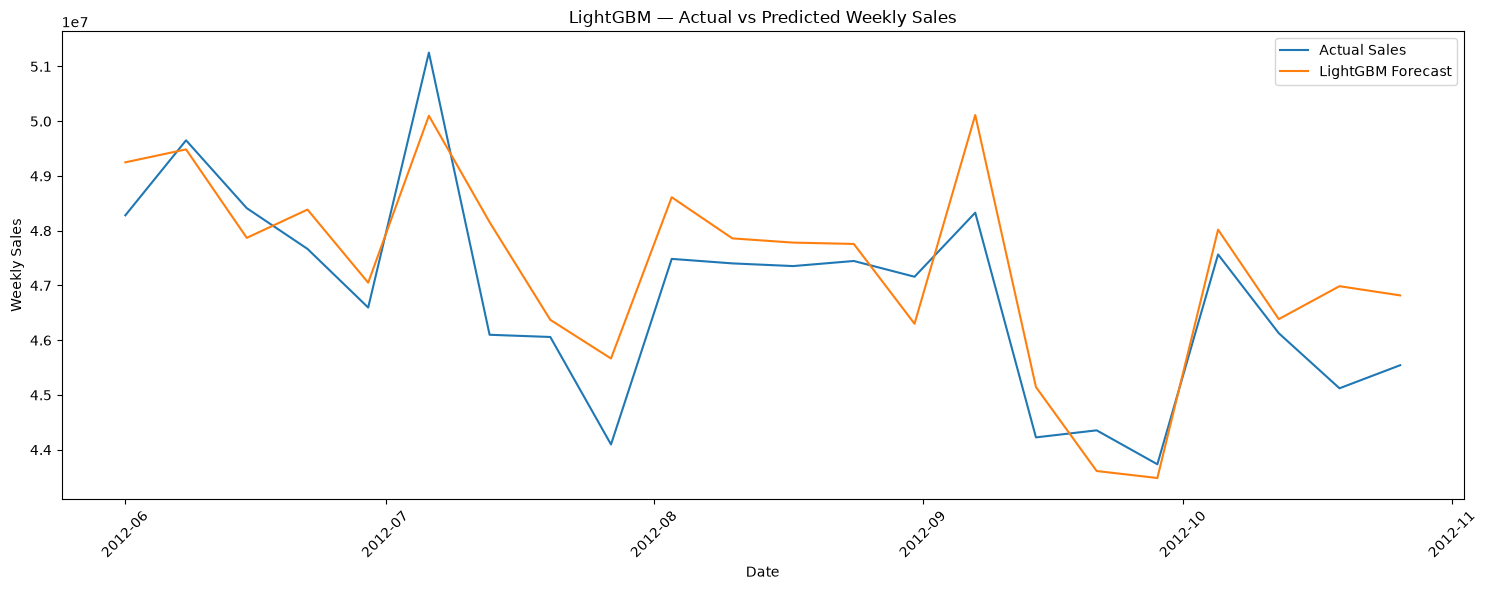

In [30]:
plt.figure(figsize=(15, 6))

plt.plot(
    weekly_lgbm["Date"],
    weekly_lgbm["Actual_Sales"],
    label="Actual Sales"
)

plt.plot(
    weekly_lgbm["Date"],
    weekly_lgbm["Predicted_Sales"],
    label="LightGBM Forecast"
)

plt.title(
    "LightGBM — Actual vs Predicted Weekly Sales"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Residual Analysis

In [31]:
#Create residuals:

lgbm_results["Residual"] = (
    lgbm_results["Weekly_Sales"]
    - lgbm_results["Predicted_Sales"]
)

In [32]:
#Check:

lgbm_results[
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales",
        "Predicted_Sales",
        "Residual"
    ]
].head(10)

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
356489,2012-06-01,1,1,16065.49,18481.847220,-2416.357220
356490,2012-06-01,1,2,47425.29,48238.678069,-813.388069
356491,2012-06-01,1,3,7175.77,9029.036889,-1853.266889
356492,2012-06-01,1,4,41566.55,40204.481931,1362.068069
356493,2012-06-01,1,5,17233.25,18666.336535,-1433.086535
356494,2012-06-01,1,6,3249.75,5011.221345,-1761.471345
356495,2012-06-01,1,7,31568.92,32620.962041,-1052.042041
356496,2012-06-01,1,8,41039.74,39279.590355,1760.149645
356497,2012-06-01,1,9,35001.66,30984.257947,4017.402053
356498,2012-06-01,1,10,37294.14,35531.650556,1762.489444


In [33]:
#Residual Statistics

lgbm_results["Residual"].describe()

count    65081.000000
mean      -172.694489
std       2558.994709
min     -66313.950133
25%       -654.292754
50%        -55.670587
75%        399.121359
max      67525.996768
Name: Residual, dtype: float64

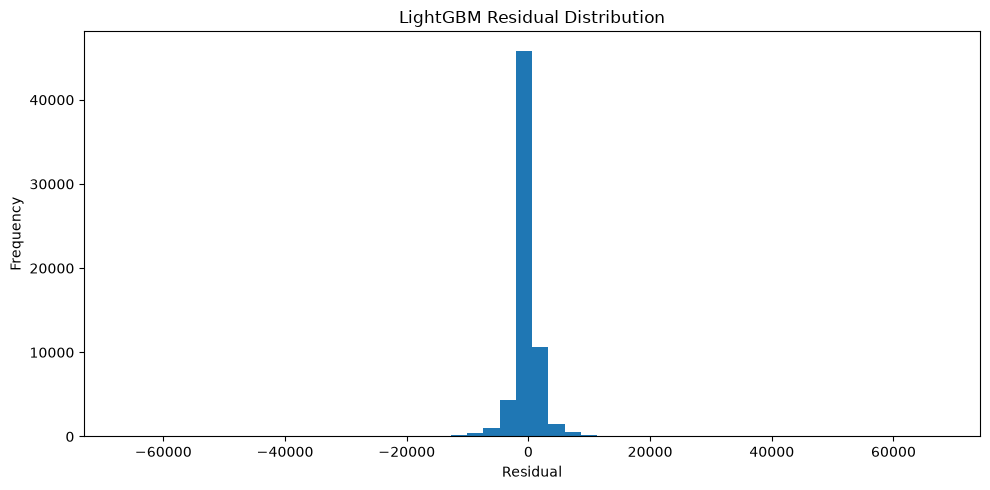

In [34]:
#Residual Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    lgbm_results["Residual"],
    bins=50
)

plt.title(
    "LightGBM Residual Distribution"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Largest Forecast Errors

In [35]:
#Largest Underpredictions

lgbm_results.nlargest(
    10,
    "Residual"
)[
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales",
        "Predicted_Sales",
        "Residual"
    ]
]

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
398664,2012-09-07,13,3,114230.60,46704.603232,67525.996768
366803,2012-06-22,22,11,60650.80,12169.941345,48480.858655
416701,2012-10-19,16,9,111246.19,66804.481084,44441.708916
379649,2012-07-20,38,38,100618.04,62041.976251,38576.063749
392743,2012-08-24,13,5,73550.30,35288.074922,38262.225078
358802,2012-06-01,35,11,76321.27,38376.971526,37944.298474
367671,2012-06-22,35,11,53862.26,17724.277981,36137.982019
366872,2012-06-22,23,11,78530.70,42457.583407,36073.116593
383654,2012-08-03,10,3,120827.95,84877.651796,35950.298204
395705,2012-08-31,13,3,91139.25,56061.481362,35077.768638


In [36]:
#Largest Overpredictions

lgbm_results.nsmallest(
    10,
    "Residual"
)[
    [
        "Date",
        "Store",
        "Dept",
        "Weekly_Sales",
        "Predicted_Sales",
        "Residual"
    ]
]

,Date,Store,Dept,Weekly_Sales,Predicted_Sales,Residual
416606,2012-10-19,14,72,69389.31,135703.260133,-66313.950133
419558,2012-10-26,14,72,63071.17,126540.430061,-63469.260061
417025,2012-10-19,20,72,63571.41,111383.801122,-47812.391122
418872,2012-10-26,4,72,90201.62,133260.573559,-43058.953559
420185,2012-10-26,23,72,51421.23,93443.597182,-42022.367182
366302,2012-06-22,14,92,134236.16,171977.621861,-37741.461861
418736,2012-10-26,2,72,48941.21,85339.585168,-36398.375168
396034,2012-08-31,17,72,39235.44,75421.441293,-36186.001293
395685,2012-08-31,12,72,41856.62,77568.129887,-35711.509887
419279,2012-10-26,10,72,121126.83,156284.198002,-35157.368002


#### Feature Importance

In [37]:
lgbm_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": lgbm_model.feature_importances_
})

In [38]:
#Sort:

lgbm_feature_importance = (
    lgbm_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

In [39]:
#Top 20:

lgbm_feature_importance.head(20)

,Feature,Importance
6,Day,1087
17,Lag_1,983
22,Lag_52,820
5,Week,778
1,Dept,741
26,Rolling_Std_4,535
44,Dept_Min_Sales,512
45,Dept_Max_Sales,511
50,Week_Sin,470
18,Lag_2,419


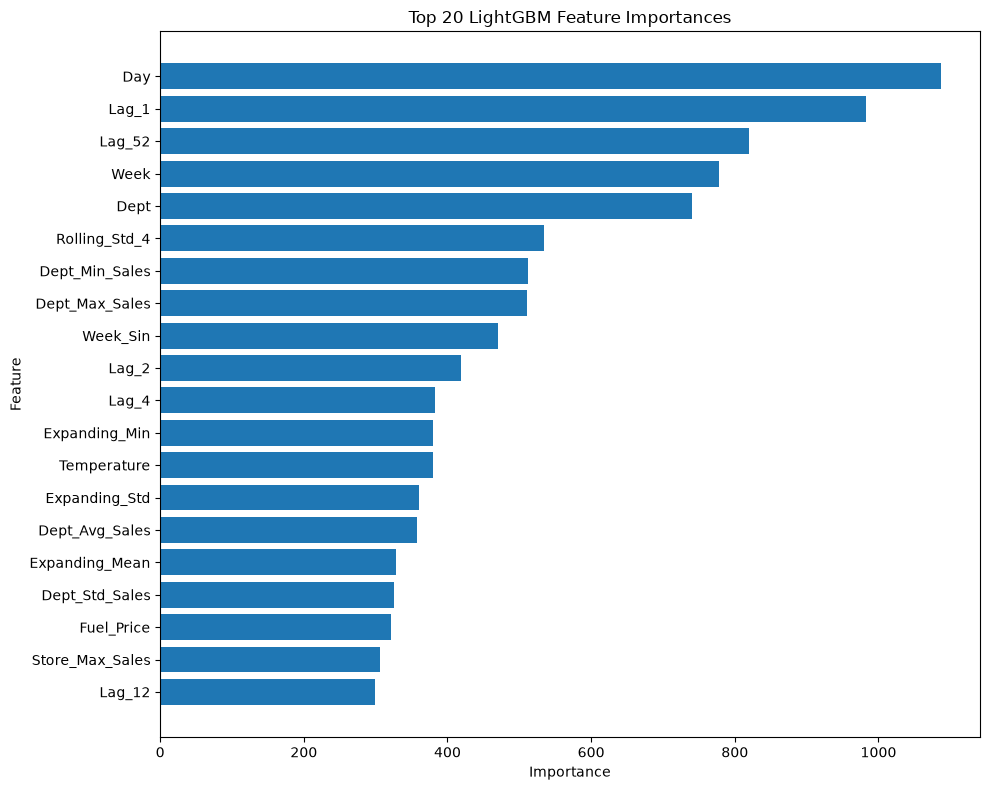

In [40]:
#Feature Importance Visualization

top_features = (
    lgbm_feature_importance
    .head(20)
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Top 20 LightGBM Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

#### Compare All Four Models

In [ ]:
baseline_results = pd.read_csv(
    "../reports/figures/baseline_summary.csv"
)

prophet_summary = pd.read_csv(
    "../reports/figures/prophet_summary.csv"
)

xgb_summary = pd.read_csv(
    "../reports/figures/xgb_summary.csv"
)

FileNotFoundError: [Errno 2] No such file or directory: '../reports/baseline_summary.csv'